# K-IDS: Preprocessing Pipeline

## 0. Install & Import Libraries

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from collections import Counter

import os
import sys


## 1. Pull Logs dari Server

In [2]:
# Get kubeconnfig context
kubeconfig_path = "/mnt/nvme0n1p11/Github/project-kIDS/ansible/kubeconfig"
os.environ['KUBECONFIG'] = kubeconfig_path

# Get total node on cluster
!kubectl get nodes

NAME              STATUS   ROLES           AGE   VERSION
217.216.110.115   Ready    worker          8d    v1.30.14
217.217.255.103   Ready    control-plane   8d    v1.30.14


In [3]:
# Pull Hubble logs
print('Pulling Hubble logs...')
!kubectl -n kube-system exec ds/cilium -- cat /var/run/cilium/hubble/events.log > hubble_raw.json

# Pull Tetragon logs
print('Pulling Tetragon logs...')
!kubectl -n kube-system logs ds/tetragon --tail=10000 > tetragon_raw.json

print('Done pulling logs!')

Pulling Hubble logs...


Pulling Tetragon logs...
Found 2 pods, using pod/tetragon-l9c69
Defaulted container "export-stdout" out of: export-stdout, tetragon
Done pulling logs!


## 2. Label Mapping

In [4]:
LABEL_MAP = {
    # Malicious Containers
    'mirai'           : 0,
    'kinsing'         : 1,
    'teamtnt'         : 1,
    'xmrig'           : 1,
    'agent'           : 2,
    'coinminer'       : 3,
    
    # Benign Containers
    'mariadb'         : 4,
    'media-streaming' : 5,
    'memcached'       : 6,
    'web-serving'     : 7,
    'web-serving-db'  : 7,
}

LABEL_NAMES = {
    0: 'Botnet (Mirai)',
    1: 'Miner (Kinsing/TeamTNT/XMRig)',
    2: 'Trojan (Agent)',
    3: 'Trojan (Coinminer)',
    4: 'Benign (MariaDB)',
    5: 'Benign (Data-Caching)',
    6: 'Benign (Media-Streaming)',
    7: 'Benign (Web-Serving)',
}

VALID_NAMESPACES = ['malicious', 'benign', 'benign-workload']

def get_label_from_pod(pod_name, namespace):
    pod_lower = pod_name.lower() if pod_name else ''
    
    for key, label in LABEL_MAP.items():
        if key in pod_lower:
            return label
    
    return -1

print('Label mapping defined!')
print('Label map:', LABEL_MAP)

Label mapping defined!
Label map: {'mirai': 0, 'kinsing': 1, 'teamtnt': 1, 'xmrig': 1, 'agent': 2, 'coinminer': 3, 'mariadb': 4, 'media-streaming': 5, 'memcached': 6, 'web-serving': 7, 'web-serving-db': 7}


## 3. Parse Tetragon Logs (Syscall)

In [5]:
def parse_tetragon_logs(filepath):
    """
    Parse Tetragon json logs.
    Extract: pod_name, namespace, syscall, binary, timestamp
    """
    records = []
    
    with open(filepath, 'r') as f:
        try:
            # parse as json array
            data = json.load(f)
            if isinstance(data, list):
                lines = data
            else:
                lines = [data]
        except json.JSONDecodeError:
            # Fallback: parse line by line (NDJSON)
            f.seek(0)
            lines = []
            for line in f:
                line = line.strip()
                if line:
                    try:
                        lines.append(json.loads(line))
                    except:
                        continue
    
    for entry in lines:
        try:
            # Handle process_kprobe events (syscall)
            if 'process_kprobe' in entry:
                kprobe = entry['process_kprobe']
                process = kprobe.get('process', {})
                pod = process.get('pod', {})
                container = pod.get('container', {})
                
                pod_name = pod.get('name', '')
                namespace = pod.get('namespace', '')
                syscall = kprobe.get('function_name', '')
                binary = process.get('binary', '')
                timestamp = entry.get('time', '')
                
                # Skip jika bukan dari namespace yang relevan
                if namespace not in ['malicious', 'benign']:
                    continue
                
                label = get_label_from_pod(pod_name, namespace)
                
                records.append({
                    'timestamp'  : timestamp,
                    'pod_name'   : pod_name,
                    'namespace'  : namespace,
                    'container'  : container.get('name', ''),
                    'binary'     : binary,
                    'syscall'    : syscall,
                    'label'      : label
                })
                
            # Handle process_exit events
            elif 'process_exit' in entry:
                process = entry['process_exit'].get('process', {})
                pod = process.get('pod', {})
                namespace = pod.get('namespace', '')
                
                if namespace not in ['malicious', 'benign']:
                    continue
                    
        except Exception as e:
            continue
    
    df = pd.DataFrame(records)
    print(f'Total Tetragon records: {len(df)}')
    return df

# Parse
tetragon_df = parse_tetragon_logs('tetragon_raw.json')
print('\nSample:')
print(tetragon_df.head())
print('\nNamespace distribution:')
print(tetragon_df['namespace'].value_counts())
print('\nLabel distribution:')
print(tetragon_df['label'].value_counts())

Total Tetragon records: 605

Sample:
                        timestamp  \
0  2026-04-28T07:06:46.218705510Z   
1  2026-04-28T07:06:46.220496182Z   
2  2026-04-28T07:06:46.225245479Z   
3  2026-04-28T07:06:46.226698665Z   
4  2026-04-28T07:06:46.228437589Z   

                                        pod_name  namespace container  \
0  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious   kinsing   
1  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious   kinsing   
2  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious   kinsing   
3  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious   kinsing   
4  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious   kinsing   

    binary           syscall  label  
0  /bin/sh  __x64_sys_execve      1  
1  /bin/sh  __x64_sys_execve      1  
2  /bin/sh  __x64_sys_execve      1  
3  /bin/sh  __x64_sys_execve      1  
4  /bin/sh  __x64_sys_execve      1  

Namespace distribution:
namespace
malicious    605
Name: count, dtype: i

## 4. Parse Hubble Logs (Network Flow)

In [6]:
def parse_hubble_logs(filepath):
    records = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                entry = json.loads(line)
            except:
                continue
            
            if 'flow' not in entry:
                continue
            
            flow        = entry['flow']
            source      = flow.get('source', {})
            destination = flow.get('destination', {})
            ip          = flow.get('IP', {})
            l4          = flow.get('l4', {})
            tcp         = l4.get('TCP', {})
            udp         = l4.get('UDP', {})
            flags       = tcp.get('flags', {})
            
            # Langsung ambil namespace & pod_name dari source
            src_namespace = source.get('namespace', '')
            dst_namespace = destination.get('namespace', '')
            src_pod       = source.get('pod_name', '')
            dst_pod       = destination.get('pod_name', '')
            
            # Prioritaskan source namespace
            if src_namespace in VALID_NAMESPACES:
                namespace = src_namespace
                pod_name  = src_pod
            elif dst_namespace in VALID_NAMESPACES:
                namespace = dst_namespace
                pod_name  = dst_pod
            else:
                continue
            
            label = get_label_from_pod(pod_name, namespace)
            
            records.append({
                'timestamp'    : flow.get('time', ''),
                'pod_name'     : pod_name,
                'namespace'    : namespace,
                'src_ip'       : ip.get('source', ''),
                'dst_ip'       : ip.get('destination', ''),
                'src_port'     : tcp.get('source_port', udp.get('source_port', 0)),
                'dst_port'     : tcp.get('destination_port', udp.get('destination_port', 0)),
                'protocol'     : 'TCP' if tcp else ('UDP' if udp else 'OTHER'),
                'verdict'      : flow.get('verdict', ''),
                'traffic_dir'  : flow.get('traffic_direction', ''),
                'is_reply'     : int(flow.get('is_reply', False)),
                # TCP Flags
                'flag_SYN'     : int(flags.get('SYN', False)),
                'flag_ACK'     : int(flags.get('ACK', False)),
                'flag_FIN'     : int(flags.get('FIN', False)),
                'flag_RST'     : int(flags.get('RST', False)),
                'flag_PSH'     : int(flags.get('PSH', False)),
                'flag_URG'     : int(flags.get('URG', False)),
                'label'        : label
            })
    
    df = pd.DataFrame(records)
    print(f'Total Hubble flow records: {len(df)}')
    return df

# Parse ulang
hubble_df = parse_hubble_logs('hubble_raw.json')
print('\nSample:')
print(hubble_df.head())
print('\nNamespace distribution:')
print(hubble_df['namespace'].value_counts())
print('\nLabel distribution:')
print(hubble_df['label'].value_counts())

Total Hubble flow records: 722

Sample:
                        timestamp  \
0  2026-04-28T07:13:13.050588767Z   
1  2026-04-28T07:13:13.050623982Z   
2  2026-04-28T07:13:14.464248661Z   
3  2026-04-28T07:13:14.464715279Z   
4  2026-04-28T07:13:14.464853416Z   

                                        pod_name        namespace  \
0                web-serving-db-6cb58cc84b-r8q2f  benign-workload   
1                web-serving-db-6cb58cc84b-r8q2f  benign-workload   
2  malicious-containers-teamtnt-657ccf7c8c-r6lhb        malicious   
3  malicious-containers-teamtnt-657ccf7c8c-r6lhb        malicious   
4  malicious-containers-teamtnt-657ccf7c8c-r6lhb        malicious   

           src_ip          dst_ip  src_port  dst_port protocol    verdict  \
0  128.178.226.68     10.42.1.254       443     41010      TCP  FORWARDED   
1     10.42.1.254  128.178.226.68     41010       443      TCP  FORWARDED   
2      10.42.1.24     10.42.1.182     56511        53      UDP  FORWARDED   
3     10.42.1.

## 5. Syscall Preprocessing: Convert to Syscall Number

In [7]:
# x86_64 syscall number mapping (common ones)
SYSCALL_MAP = {
    '__x64_sys_read'        : 0,
    '__x64_sys_write'       : 1,
    '__x64_sys_open'        : 2,
    '__x64_sys_close'       : 3,
    '__x64_sys_stat'        : 4,
    '__x64_sys_fstat'       : 5,
    '__x64_sys_mmap'        : 9,
    '__x64_sys_mprotect'    : 10,
    '__x64_sys_munmap'      : 11,
    '__x64_sys_brk'         : 12,
    '__x64_sys_rt_sigaction': 13,
    '__x64_sys_rt_sigreturn': 15,
    '__x64_sys_ioctl'       : 16,
    '__x64_sys_access'      : 21,
    '__x64_sys_sched_yield' : 24,
    '__x64_sys_nanosleep'   : 35,
    '__x64_sys_sendto'      : 44,
    '__x64_sys_recvfrom'    : 45,
    '__x64_sys_socket'      : 41,
    '__x64_sys_connect'     : 42,
    '__x64_sys_accept'      : 43,
    '__x64_sys_clone'       : 56,
    '__x64_sys_fork'        : 57,
    '__x64_sys_execve'      : 59,
    '__x64_sys_exit'        : 60,
    '__x64_sys_wait4'       : 61,
    '__x64_sys_kill'        : 62,
    '__x64_sys_openat'      : 257,
    '__x64_sys_epoll_pwait' : 281,
    '__x64_sys_newfstatat'  : 262,
}

def convert_syscall_to_number(syscall_name):
    """
    Convert syscall name ke number.
    Kalau tidak ada di map, assign berdasarkan hash.
    """
    if syscall_name in SYSCALL_MAP:
        return SYSCALL_MAP[syscall_name]
    # Untuk syscall yang tidak ada di map
    return hash(syscall_name) % 500

# Apply conversion
tetragon_df['syscall_number'] = tetragon_df['syscall'].apply(convert_syscall_to_number)

print('Syscall conversion done!')
print('\nUnique syscalls found:')
print(tetragon_df['syscall'].value_counts().head(20))

Syscall conversion done!

Unique syscalls found:
syscall
__x64_sys_socket     390
__x64_sys_execve     137
__x64_sys_connect     78
Name: count, dtype: int64


## 6. Syscall Preprocessing: 5-gram Tokenization

In [8]:
def generate_ngrams(sequence, n=5):
    """
    Generate overlapping n-gram sequences.
    """
    ngrams = []
    for i in range(len(sequence) - n + 1):
        ngrams.append(tuple(sequence[i:i+n]))
    return ngrams

# Group syscall sequence per pod
syscall_sequences = tetragon_df.groupby(
    ['pod_name', 'namespace', 'label']
)['syscall_number'].apply(list).reset_index()

syscall_sequences.columns = ['pod_name', 'namespace', 'label', 'syscall_sequence']

# Generate 5-grams
syscall_sequences['ngrams'] = syscall_sequences['syscall_sequence'].apply(
    lambda x: generate_ngrams(x, n=5)
)

print('5-gram generation done!')
print(f'Total pods: {len(syscall_sequences)}')
print('\nSample ngrams (first pod):')
print(syscall_sequences['ngrams'].iloc[0][:5])

5-gram generation done!
Total pods: 2

Sample ngrams (first pod):
[(59, 59, 59, 59, 59), (59, 59, 59, 59, 59), (59, 59, 59, 59, 59), (59, 59, 59, 59, 59), (59, 59, 59, 59, 59)]


In [9]:
# Flatten ngrams ke DataFrame untuk ML
ngram_records = []

for _, row in syscall_sequences.iterrows():
    for ngram in row['ngrams']:
        ngram_records.append({
            'pod_name'  : row['pod_name'],
            'namespace' : row['namespace'],
            'label'     : row['label'],
            'n1'        : ngram[0],
            'n2'        : ngram[1],
            'n3'        : ngram[2],
            'n4'        : ngram[3],
            'n5'        : ngram[4],
        })

syscall_ml_df = pd.DataFrame(ngram_records)

print(f'Total 5-gram instances: {len(syscall_ml_df)}')
print('\nLabel distribution:')
print(syscall_ml_df['label'].value_counts())
print('\nSample:')
print(syscall_ml_df.head())

Total 5-gram instances: 597

Label distribution:
label
1    597
Name: count, dtype: int64

Sample:
                                        pod_name  namespace  label  n1  n2  \
0  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious      1  59  59   
1  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious      1  59  59   
2  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious      1  59  59   
3  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious      1  59  59   
4  malicious-containers-kinsing-5c4cffd87c-t7f5q  malicious      1  59  59   

   n3  n4  n5  
0  59  59  59  
1  59  59  59  
2  59  59  59  
3  59  59  59  
4  59  59  59  


## 7. Network Flow Preprocessing

In [10]:
# Drop identifier fields (prevent label leakage)
drop_cols = ['timestamp', 'pod_name', 'namespace', 'src_ip', 'dst_ip', 
             'src_port', 'dst_port']

hubble_features = hubble_df.drop(
    columns=[c for c in drop_cols if c in hubble_df.columns]
)

# One-hot encode protocol dan verdict
hubble_features = pd.get_dummies(
    hubble_features, 
    columns=['protocol', 'verdict', 'traffic_dir'],
    prefix=['proto', 'verdict', 'dir']
)

# Fill missing values dengan 0
hubble_features = hubble_features.fillna(0)

# Filter hanya label yang valid
hubble_features = hubble_features[hubble_features['label'] >= 0]

print('Network flow preprocessing done!')
print(f'Total records: {len(hubble_features)}')
print(f'Total features: {hubble_features.shape[1]}')
print('\nFeatures:')
print(hubble_features.columns.tolist())

Network flow preprocessing done!
Total records: 722
Total features: 12

Features:
['is_reply', 'flag_SYN', 'flag_ACK', 'flag_FIN', 'flag_RST', 'flag_PSH', 'flag_URG', 'label', 'proto_TCP', 'proto_UDP', 'verdict_FORWARDED', 'dir_EGRESS']


## 8. Feature Selection: SelectKBest + Chi-Square (Network Flow)

Selected top 11 features:
  1. is_reply
  2. flag_SYN
  3. flag_ACK
  4. flag_FIN
  5. flag_RST
  6. flag_PSH
  7. flag_URG
  8. proto_TCP
  9. proto_UDP
  10. verdict_FORWARDED
  11. dir_EGRESS


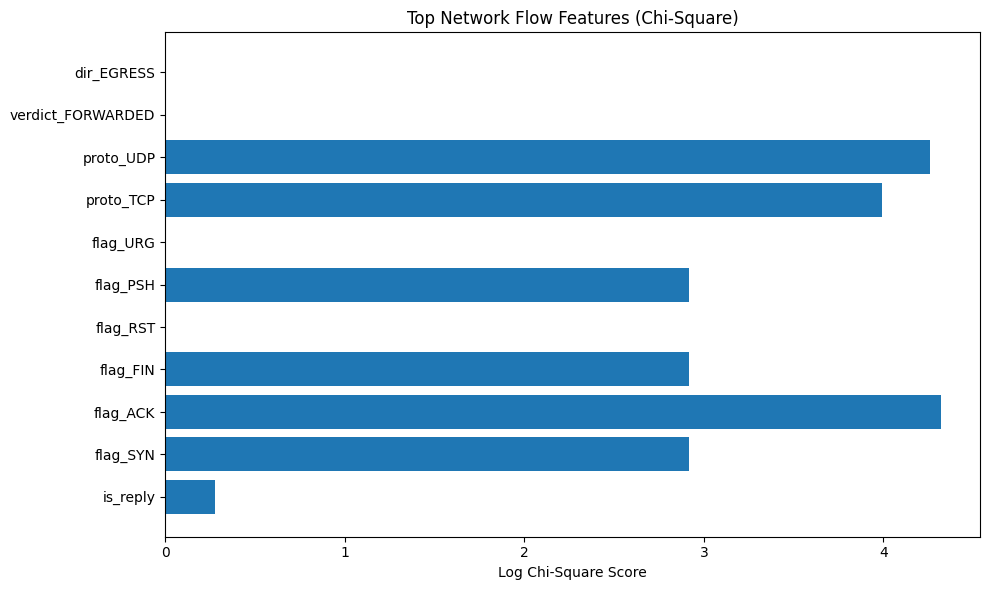

In [11]:
from sklearn.feature_selection import SelectKBest, chi2

X_flow = hubble_features.drop(columns=['label'])
y_flow = hubble_features['label']

X_flow = X_flow.abs()

k = min(20, X_flow.shape[1])  # Fallback kalau features < 20
selector = SelectKBest(chi2, k=k)
X_flow_selected = selector.fit_transform(X_flow, y_flow)

# Lihat top features
selected_mask = selector.get_support()
selected_features = X_flow.columns[selected_mask].tolist()

print(f'Selected top {k} features:')
for i, feat in enumerate(selected_features):
    print(f'  {i+1}. {feat}')

# Plot feature importance
scores = selector.scores_[selected_mask]
plt.figure(figsize=(10, 6))
plt.barh(selected_features, np.log1p(scores))
plt.xlabel('Log Chi-Square Score')
plt.title('Top Network Flow Features (Chi-Square)')
plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150)
plt.show()

## 9. Train/Test Split

In [12]:
# --- Syscall Dataset ---
syscall_valid = syscall_ml_df[syscall_ml_df['label'] >= 0].copy()
X_syscall = syscall_valid[['n1', 'n2', 'n3', 'n4', 'n5']]
y_syscall = syscall_valid['label']

X_train_sys, X_test_sys, y_train_sys, y_test_sys = train_test_split(
    X_syscall, y_syscall,
    test_size=0.3,
    random_state=42,
    stratify=y_syscall
)

print('=== Syscall Dataset ===')
print(f'Train size: {len(X_train_sys)}')
print(f'Test size : {len(X_test_sys)}')
print('Train label distribution:')
print(y_train_sys.value_counts())

# --- Network Flow Dataset ---
X_train_flow, X_test_flow, y_train_flow, y_test_flow = train_test_split(
    X_flow_selected, y_flow,
    test_size=0.3,
    random_state=42,
    stratify=y_flow
)

print('\n=== Network Flow Dataset ===')
print(f'Train size: {len(X_train_flow)}')
print(f'Test size : {len(X_test_flow)}')
print('Train label distribution:')
print(pd.Series(y_train_flow).value_counts())

=== Syscall Dataset ===
Train size: 417
Test size : 180
Train label distribution:
label
1    417
Name: count, dtype: int64

=== Network Flow Dataset ===
Train size: 505
Test size : 217
Train label distribution:
label
1    413
7     92
Name: count, dtype: int64


## 10. Check Class Imbalance

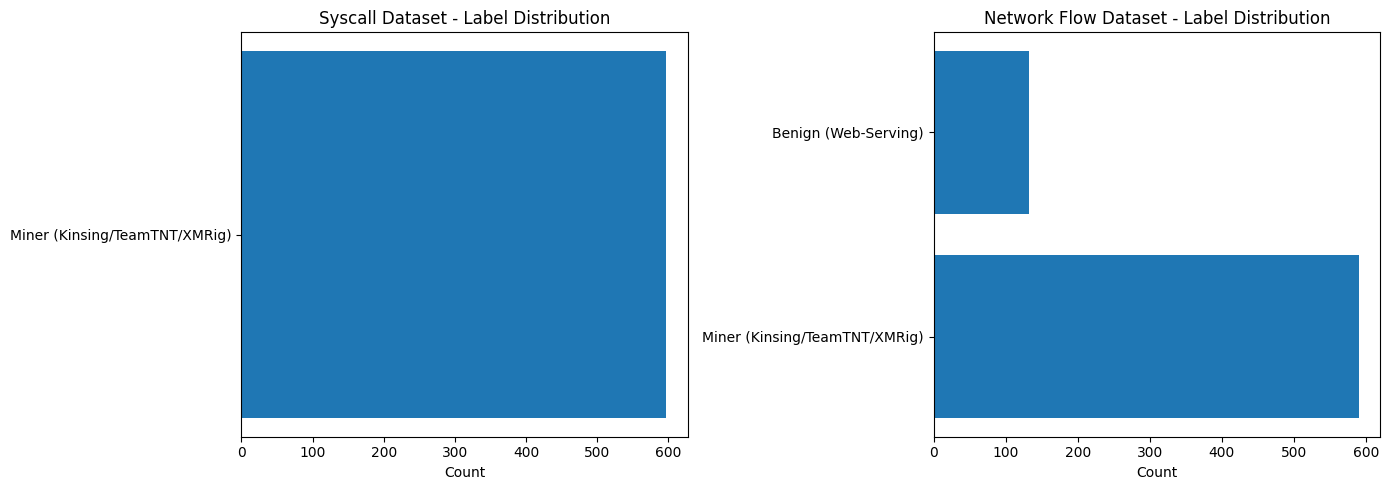

Label distribution plot saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Syscall
syscall_counts = y_syscall.map(LABEL_NAMES).value_counts()
axes[0].barh(syscall_counts.index, syscall_counts.values)
axes[0].set_title('Syscall Dataset - Label Distribution')
axes[0].set_xlabel('Count')

# Network flow
flow_counts = pd.Series(y_flow).map(LABEL_NAMES).value_counts()
axes[1].barh(flow_counts.index, flow_counts.values)
axes[1].set_title('Network Flow Dataset - Label Distribution')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()
print('Label distribution plot saved!')

## 11. Save Preprocessed Datasets

In [14]:
# Save syscall dataset
syscall_valid.to_csv('syscall_dataset.csv', index=False)
print('Syscall dataset saved: syscall_dataset.csv')

# Save network flow dataset
flow_df_selected = pd.DataFrame(
    X_flow_selected, 
    columns=selected_features
)
flow_df_selected['label'] = y_flow.values
flow_df_selected.to_csv('network_flow_dataset.csv', index=False)
print('Network flow dataset saved: network_flow_dataset.csv')

# Save selector & scaler untuk IDS pipeline
joblib.dump(selector, 'feature_selector.pkl')
joblib.dump(selected_features, 'selected_features.pkl')
print('Feature selector saved: feature_selector.pkl')

print('\n=== Summary ===')
print(f'Syscall dataset    : {len(syscall_valid)} instances')
print(f'Network flow dataset: {len(flow_df_selected)} instances')
print(f'Selected features  : {selected_features}')

Syscall dataset saved: syscall_dataset.csv
Network flow dataset saved: network_flow_dataset.csv
Feature selector saved: feature_selector.pkl

=== Summary ===
Syscall dataset    : 597 instances
Network flow dataset: 722 instances
Selected features  : ['is_reply', 'flag_SYN', 'flag_ACK', 'flag_FIN', 'flag_RST', 'flag_PSH', 'flag_URG', 'proto_TCP', 'proto_UDP', 'verdict_FORWARDED', 'dir_EGRESS']
